In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu
import folium
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm
import sqlite3

In [27]:
df_BarcelonaSept24 = pd.read_csv(r'C:\Users\alber\Downloads\listingsB06Sep24.csv')
df_BarcelonaJune24 =pd.read_csv(r'C:\Users\alber\Downloads\listingsB15June24.csv')
df_BarcelonaMarch24 = pd.read_csv(r'C:\Users\alber\Downloads\listingsB20March24.csv')
df_BarcelonaDec23 = pd.read_csv(r'C:\Users\alber\Downloads\listingsB13Dec23.csv')
df_BarcelonaMarch25 = pd.read_csv(r'C:\Users\alber\Downloads\listingsBarcelonaMarch2025.csv')
df_SevillaJune24 = pd.read_csv(r'C:\Users\alber\Downloads\listingsS30June24.csv')
df_SevillaMarch24 = pd.read_csv(r'C:\Users\alber\Downloads\listingsS31March24.csv')
df_SevillaDec23 = pd.read_csv(r'C:\Users\alber\Downloads\listingsS29Dec23.csv')
df_MadridSept24 = pd.read_csv(r'C:\Users\alber\Downloads\listingsM11Sep24.csv')
df_MadridJune24 = pd.read_csv(r'C:\Users\alber\Downloads\listingsM15June24.csv')
df_MadridMarch24 = pd.read_csv(r'C:\Users\alber\Downloads\listingsM22March24.csv')
df_MadridDec23 = pd.read_csv(r'C:\Users\alber\Downloads\listingsM15Dec23.csv')
df_MadridMarch25 = pd.read_csv(r'C:\Users\alber\Downloads\listingsMadridMarch2025.csv')

In [28]:
df_BSept24_copia = df_BarcelonaSept24.copy()
df_BMarch24_copia = df_BarcelonaMarch24.copy()
df_BJune24_copia = df_BarcelonaJune24.copy()
df_BDec23_copia = df_BarcelonaDec23.copy()
df_BMarch25_copia = df_BarcelonaMarch25.copy()

df_MDec23_copia = df_MadridDec23.copy()
df_MJune24_copia = df_MadridJune24.copy()
df_MSept24_copia = df_MadridSept24.copy()
df_MMarch24_copia = df_MadridMarch24.copy()
df_MMarch25_copia = df_MadridMarch25.copy()

df_SJune24_copia = df_SevillaJune24.copy()
df_SMarch24_copia = df_SevillaMarch24.copy()
df_SDec23_copia = df_BarcelonaDec23.copy()

df_BSept24_copia['month'] = 'September'
df_BMarch24_copia['month'] = 'March'
df_BJune24_copia['month'] = 'June'
df_BDec23_copia['month'] = 'December'  
df_BMarch25_copia['month'] = 'March'


df_MDec23_copia['month'] = 'December'
df_MJune24_copia['month'] = 'June'
df_MSept24_copia['month'] = 'September'
df_MMarch24_copia['month'] = 'March'
df_MMarch25_copia['month'] = 'March'


df_SJune24_copia['month'] = 'June'
df_SMarch24_copia['month'] = 'March'
df_SDec23_copia['month'] = 'December'

df_BSept24_copia['state'] = 'Barcelona'
df_BMarch24_copia['state'] = 'Barcelona'
df_BJune24_copia['state'] = 'Barcelona'
df_BDec23_copia['state'] = 'Barcelona' 
df_MMarch25_copia['state'] = 'Barcelona'
 

df_MDec23_copia['state'] = 'Madrid'
df_MJune24_copia['state'] = 'Madrid'
df_MSept24_copia['state'] = 'Madrid'
df_MMarch24_copia['state'] = 'Madrid'
df_MMarch25_copia['state'] = 'Madrid'


df_SJune24_copia['state'] = 'Sevilla'
df_SMarch24_copia['state'] = 'Sevilla'
df_SDec23_copia['state'] = 'Sevilla'

df_concatenado1_total = pd.concat([df_BSept24_copia, df_BMarch24_copia, df_BJune24_copia, df_BDec23_copia, df_MSept24_copia, df_MMarch24_copia, df_MJune24_copia, df_MDec23_copia, df_SMarch24_copia, df_SJune24_copia, df_SDec23_copia, df_BMarch25_copia, df_MMarch25_copia ], ignore_index=True)

df_concatenado1_total.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259472 entries, 0 to 259471
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              259472 non-null  object 
 1   name                            253941 non-null  object 
 2   host_id                         253940 non-null  object 
 3   host_name                       253885 non-null  object 
 4   neighbourhood_group             253940 non-null  object 
 5   neighbourhood                   253940 non-null  object 
 6   latitude                        253940 non-null  float64
 7   longitude                       253940 non-null  object 
 8   room_type                       253940 non-null  object 
 9   price                           207603 non-null  float64
 10  minimum_nights                  253940 non-null  float64
 11  number_of_reviews               253940 non-null  object 
 12  last_review     

In [62]:
df_concatenado1_total.info()
df_concatenado1_total.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259472 entries, 0 to 259471
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              259472 non-null  object 
 1   name                            253941 non-null  object 
 2   host_id                         253940 non-null  object 
 3   host_name                       253885 non-null  object 
 4   neighbourhood_group             253940 non-null  object 
 5   neighbourhood                   253940 non-null  object 
 6   latitude                        253940 non-null  float64
 7   longitude                       253940 non-null  object 
 8   room_type                       253940 non-null  object 
 9   price                           207603 non-null  float64
 10  minimum_nights                  253940 non-null  float64
 11  number_of_reviews               253940 non-null  object 
 12  last_review     

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,month,state,license;
0,18674,Huge flat for 8 people close to Sagrada Familia,71615,Mireia Maria,Eixample,la Sagrada Família,41.405560,2.17262,Entire home/apt,194.0,...,42,2024-06-03,0.31,28.0,72.0,3,HUTB-002062,September,Barcelona,NaN
1,23197,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",90417,Etain (Marnie),Sant Martí,el Besòs i el Maresme,41.412432,2.21975,Entire home/apt,304.0,...,79,2024-06-24,0.48,1.0,116.0,7,HUTB005057,September,Barcelona,NaN
2,32711,Sagrada Familia area - Còrsega 1,135703,Nick,Gràcia,el Camp d'en Grassot i Gràcia Nova,41.405660,2.17015,Entire home/apt,211.0,...,128,2024-09-05,0.80,3.0,319.0,32,HUTB-001722,September,Barcelona,NaN
3,34241,Stylish Top Floor Apartment - Ramblas Plaza Real,73163,Andres,Ciutat Vella,el Barri Gòtic,41.380620,2.17517,Entire home/apt,300.0,...,20,2024-08-20,0.12,3.0,69.0,12,Exempt,September,Barcelona,NaN
4,34981,VIDRE HOME PLAZA REAL on LAS RAMBLAS,73163,Andres,Ciutat Vella,el Barri Gòtic,41.379780,2.17623,Entire home/apt,314.0,...,247,2024-09-02,1.46,3.0,241.0,37,HUTB-150671,September,Barcelona,NaN


In [29]:
df_concatenado1_total.to_csv(r'C:\Users\alber\OneDrive\Escritorio\Data\DataSetConjunto1.csv', index=False)

In [30]:

# Concatenar los DataFrames
df_concatenado1_Barcelona = pd.concat([df_BSept24_copia, df_BMarch24_copia, df_BJune24_copia, df_BDec23_copia, df_BarcelonaMarch25], ignore_index=True)


# Concatenar los DataFrames
df_concatenado1_Madrid = pd.concat([df_MSept24_copia, df_MMarch24_copia, df_MJune24_copia, df_MDec23_copia, df_MMarch25_copia], ignore_index=True)


# Concatenar los DataFrames
df_concatenado1_Sevilla = pd.concat([df_SMarch24_copia, df_SJune24_copia, df_SDec23_copia], ignore_index=True)




In [31]:
import pandas as pd
import numpy as np

# Cargar los datos con low_memory=False para evitar el warning
file_path = r'C:\Users\alber\OneDrive\Escritorio\Data\DataSetConjunto1.csv'
data = pd.read_csv(file_path, low_memory=False)

# 1️⃣ Eliminar columnas irrelevantes
drop_columns = ['id', 'host_id', 'host_name', 'license', 'license;']
data = data.drop(columns=drop_columns, errors='ignore')

# 2️⃣ Corrección de tipos de datos
data['longitude'] = pd.to_numeric(data['longitude'], errors='coerce')
data['number_of_reviews'] = pd.to_numeric(data['number_of_reviews'], errors='coerce')
data['number_of_reviews_ltm'] = pd.to_numeric(data['number_of_reviews_ltm'], errors='coerce')
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

# 3️⃣ Manejo de valores nulos
# Imputar precio con la mediana (solo si hay valores nulos)
data['price'] = data['price'].fillna(data['price'].median())

# Imputar reviews_per_month con 0
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)

# Reemplazar last_review con la fecha más antigua si es NaT
data['last_review'] = data['last_review'].fillna(data['last_review'].min())

# Imputar state con el modo si es necesario
data['state'] = data['state'].fillna(data['state'].mode()[0])

# 4️⃣ Ingeniería de características
# Crear "días desde la última reseña"
data['days_since_last_review'] = (pd.to_datetime('today') - data['last_review']).dt.days

# Crear "densidad de reseñas"
data['review_density'] = data['number_of_reviews'] / (data['minimum_nights'] + 1)

# Transformar precio en logaritmo para reducir sesgo
data['log_price'] = np.log1p(data['price'])

# 5️⃣ Codificación One-Hot Encoding para variables categóricas
data = pd.get_dummies(data, columns=['neighbourhood_group', 'neighbourhood', 'room_type'], drop_first=True)

# Guardar el dataset limpio
data.to_csv(r'C:\Users\alber\OneDrive\Escritorio\Data\datos_procesados.csv', index=False)

print("Preprocesamiento completado. Datos guardados en 'datos_procesados.csv'")


Preprocesamiento completado. Datos guardados en 'datos_procesados.csv'


In [32]:
data.head()


,name,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,...,neighbourhood_la Vila Olímpica del Poblenou,neighbourhood_la Vila de Gràcia,neighbourhood_les Corts,neighbourhood_les Roquetes,neighbourhood_les Tres Torres,neighbourhood_no asignado,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,Huge flat for 8 people close to Sagrada Familia,41.405560,2.17262,194.0,1.0,42.0,2024-06-03,0.31,28.0,72.0,...,False,False,False,False,False,False,True,False,False,False
1,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",41.412432,2.21975,304.0,3.0,79.0,2024-06-24,0.48,1.0,116.0,...,False,False,False,False,False,False,True,False,False,False
2,Sagrada Familia area - Còrsega 1,41.405660,2.17015,211.0,1.0,128.0,2024-09-05,0.80,3.0,319.0,...,False,False,False,False,False,False,True,False,False,False
3,Stylish Top Floor Apartment - Ramblas Plaza Real,41.380620,2.17517,300.0,5.0,20.0,2024-08-20,0.12,3.0,69.0,...,False,False,False,False,False,False,True,False,False,False
4,VIDRE HOME PLAZA REAL on LAS RAMBLAS,41.379780,2.17623,314.0,5.0,247.0,2024-09-02,1.46,3.0,241.0,...,False,False,False,False,False,False,True,False,False,False


In [33]:
data.isnull().sum()


name                         5531
latitude                     5532
longitude                    5533
price                           0
minimum_nights               5532
                             ... 
neighbourhood_no asignado       0
room_type_Entire home/apt       0
room_type_Hotel room            0
room_type_Private room          0
room_type_Shared room           0
Length: 365, dtype: int64

<Axes: >

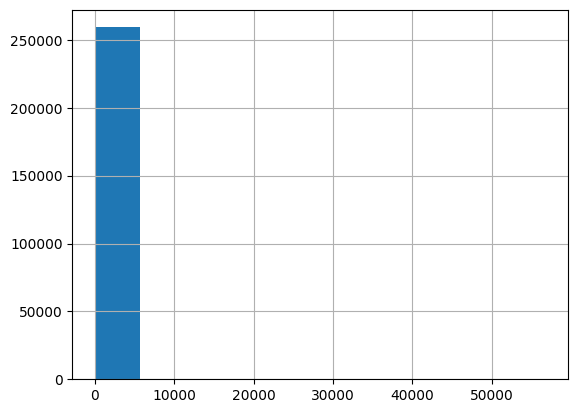

In [34]:
data['price'].hist()


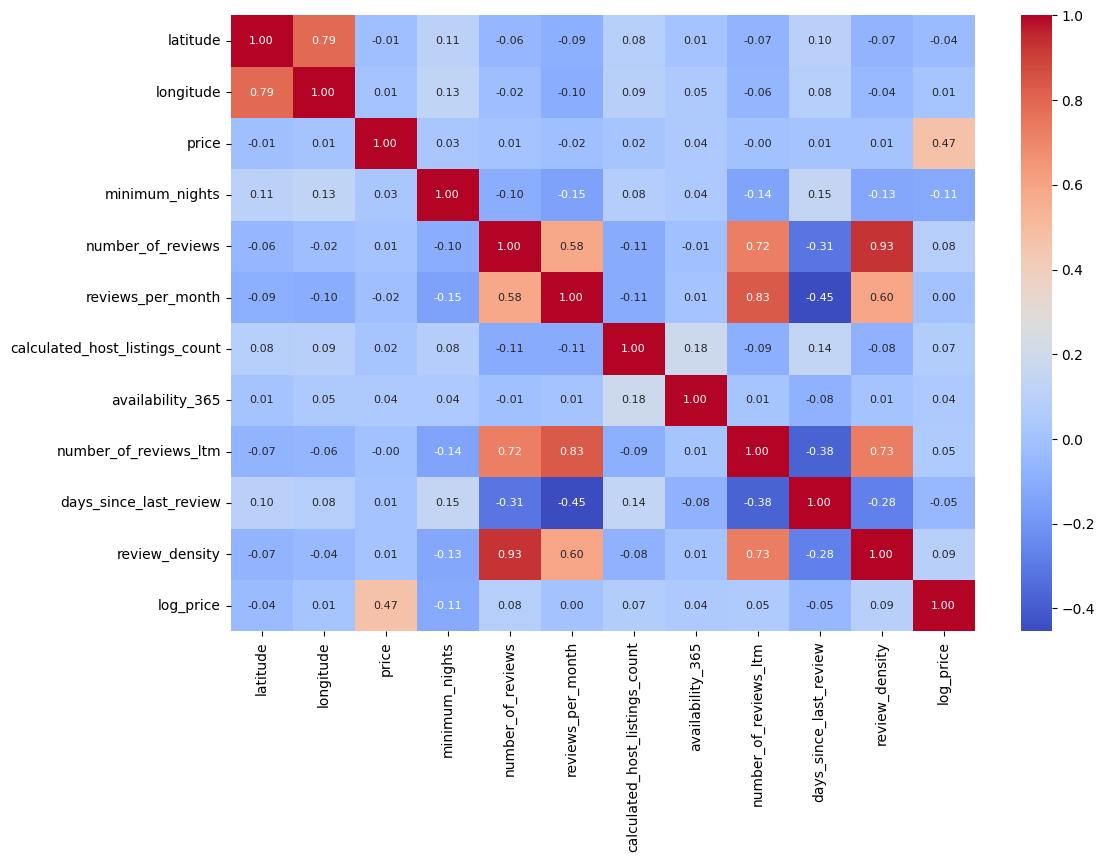

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecciona solo las columnas numéricas
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Crea la figura con un tamaño más grande para evitar que los valores se pisen
plt.figure(figsize=(12, 8))

# Genera el heatmap con ajustes en el tamaño de la fuente
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt='.2f')

# Muestra el gráfico
plt.show()


In [36]:
data['name'].value_counts()


name
Rental unit in Barcelona · 1 bedroom · 1 bed · 1 bath           1722
Rental unit in Barcelona · 1 bedroom · 1 bed · 1 shared bath    1210
Rental unit in Madrid · 1 bedroom · 1 bed · 1 bath              1152
Rental unit in Barcelona · 2 bedrooms · 2 beds · 1 bath          668
Rental unit in Madrid · 1 bedroom · 1 bed · 1 shared bath        641
                                                                ... 
Discover Chamberí: Elegant Attic with Charm                        1
Cosy Bedroom in Anton Martin                                       1
Madrid center TV Room                                              1
A1. Oasis Urbano en pleno Centro de Madrid                         1
Tropical apartment Madrid                                          1
Name: count, Length: 86398, dtype: int64

In [37]:
data['reviews_per_month'] = data['reviews_per_month'].fillna(data['reviews_per_month'].median())


In [38]:
print(data.columns)


Index(['name', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       ...
       'neighbourhood_la Vila Olímpica del Poblenou',
       'neighbourhood_la Vila de Gràcia', 'neighbourhood_les Corts',
       'neighbourhood_les Roquetes', 'neighbourhood_les Tres Torres',
       'neighbourhood_no asignado', 'room_type_Entire home/apt',
       'room_type_Hotel room', 'room_type_Private room',
       'room_type_Shared room'],
      dtype='object', length=365)


In [39]:
# Verificar las columnas codificadas
print(data[['room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']].head())

# Realizar análisis o transformación adicional si es necesario


   room_type_Entire home/apt  room_type_Hotel room  room_type_Private room  \
0                       True                 False                   False   
1                       True                 False                   False   
2                       True                 False                   False   
3                       True                 False                   False   
4                       True                 False                   False   

   room_type_Shared room  
0                  False  
1                  False  
2                  False  
3                  False  
4                  False  


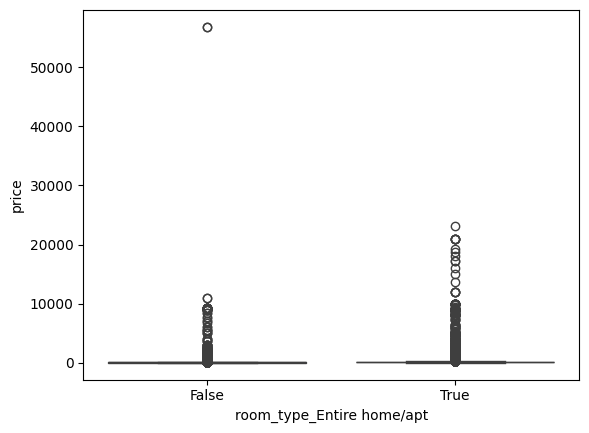

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la relación entre el tipo de habitación y el precio
sns.boxplot(x='room_type_Entire home/apt', y='price', data=data)
plt.show()


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[['latitude', 'longitude', 'minimum_nights', 'number_of_reviews']] = scaler.fit_transform(data[['latitude', 'longitude', 'minimum_nights', 'number_of_reviews']])


In [43]:
from sklearn.model_selection import train_test_split

X = data.drop('price', axis=1)  # Variables predictoras
y = data['price']  # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [46]:
print(len(X_train), len(y_train))


203158 207577


In [47]:
# Asegúrate de que ambas variables tengan el mismo número de filas
X_train = X_train.dropna()
y_train = y_train[X_train.index]  # Sincronizar índices

# Reiniciar los índices de ambas variables
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Verifica que las longitudes coinciden
print(len(X_train), len(y_train))

# Entrenar el modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


203158 203158


LinearRegression()

In [48]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


LinearRegression()

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [50]:
print(X_train.dtypes)


latitude                          float64
longitude                         float64
minimum_nights                    float64
number_of_reviews                 float64
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
days_since_last_review              int64
review_density                    float64
log_price                         float64
dtype: object


In [51]:
X_train.select_dtypes(include=['object']).columns


Index([], dtype='object')

In [52]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


In [54]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [55]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_reg.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

nn_model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Definir explícitamente la entrada
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

nn_model.compile(optimizer='adam', loss='mean_squared_error')

nn_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 90841.4375 - val_loss: 166607.5469
Epoch 2/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 97110.6797 - val_loss: 163661.6406
Epoch 3/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 108560.3438 - val_loss: 162249.5781
Epoch 4/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 117807.7969 - val_loss: 161450.4219
Epoch 5/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 90229.8672 - val_loss: 168781.7812
Epoch 6/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 121381.5156 - val_loss: 156992.8281
Epoch 7/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 85403.7109 - val_loss: 157071.1562
Epoch 8/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 63676.3828 - val_loss: 152546.8281
Epoch 9/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 129733.1875 - val_loss: 151129.2344
Epoch 10/50
5079/5079 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 60626.0586 - val_loss: 156010.7031
Epoch 11/50
5079/5079 ━━━

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = rf_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")



RMSE: 81.40376893544705
MAE: 0.6834348203102418


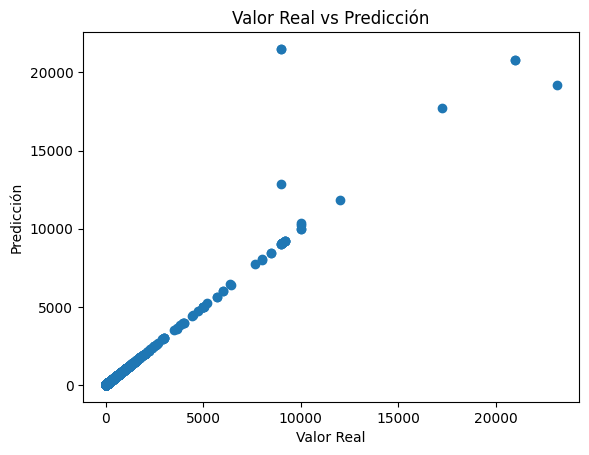

In [58]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.title('Valor Real vs Predicción')
plt.show()
